#  Week 3: Statistics & Probability

## Analyst Lab Africa Data Science Internship

### Prepared by:
**Konya Lavanne Hope Chisira**

---

## Overview

This notebook explores the fundamental concepts of Statistics and Probability using Python. The analysis focuses on descriptive statistics, probability distributions, sampling techniques, confidence intervals, hypothesis testing, and correlation analysis.

The objective is to understand how statistical methods help transform raw data into reliable insights for data-driven decision-making.

#  Objectives

By the end of this notebook, The aim is to:

- Understand descriptive statistics.
- Compute measures of central tendency.
- Analyze measures of dispersion.
- Explore probability concepts.
- Understand probability distributions.
- Demonstrate sampling techniques.
- Calculate confidence intervals.
- Perform hypothesis testing.
- Investigate relationships using correlation analysis.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")

%matplotlib inline

#  About Statistics

Statistics is the science of collecting, organizing, analyzing, interpreting, and presenting data. It enables analysts to summarize datasets, identify trends, make predictions, and support evidence-based decision-making.

Statistics is broadly divided into:

- Descriptive Statistics
- Inferential Statistics

#  Loading the Dataset

Before performing any statistical analysis, we first load the dataset into a Pandas DataFrame. This allows us to inspect its structure and prepare it for statistical computations.

The dataset used in this notebook is the Housing Prices dataset, which contains numerical and categorical variables describing residential properties and their corresponding selling prices.

In [2]:
# Loading the dataset

df = pd.read_csv("Housing.csv")

# Displaying the first five rows

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#  Dataset Overview

Understanding the structure of the dataset is an important first step before conducting any statistical analysis.

The following information helps us determine:

- Number of observations
- Number of variables
- Data types
- Missing values
- Overall data quality

In [3]:
# Dataset dimensions

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Dataset information

df.info()

Rows: 545
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


#  Statistical Summary

Descriptive statistics provide a quick overview of the numerical variables within the dataset.

They summarize the distribution of each variable by reporting:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

These statistics provide an initial understanding of the dataset before deeper analysis.

In [4]:
# Descriptive statistics

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


#  Descriptive Statistics (Categorical Variables)

While numerical variables are summarized using statistical measures, categorical variables are summarized differently.

For categorical features, we examine:

- Number of observations
- Number of unique categories
- Most frequent category (Mode)
- Frequency of the most common category

This helps us understand the composition of categorical data.

In [5]:
df.describe(include="object")

C:\Users\konya\AppData\Local\Temp\ipykernel_15448\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


#  Measures of Central Tendency

Measures of Central Tendency describe the central or typical value within a dataset.

The three primary measures are:

- Mean
- Median
- Mode

Each measure provides a different perspective on the center of the data distribution.

## Mean

The **mean** is the arithmetic average of all observations.

The mean is sensitive to extreme values (outliers), making it most suitable for relatively symmetric distributions.

In [6]:
numeric_columns = df.select_dtypes(include=np.number)

numeric_columns.mean()

price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1.286239e+00
stories      1.805505e+00
parking      6.935780e-01
dtype: float64

## Median

The **median** is the middle value after arranging the observations in ascending order.

Unlike the mean, the median is resistant to outliers and provides a better measure of central tendency for skewed data.

In [7]:
numeric_columns.median()

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64

## Mode

The **mode** is the value that occurs most frequently within a dataset.

Unlike the mean and median, the mode can be calculated for both numerical and categorical variables.

In [8]:
df.mode().iloc[0]

price                      3500000
area                        6000.0
bedrooms                       3.0
bathrooms                      1.0
stories                        2.0
mainroad                       yes
guestroom                       no
basement                        no
hotwaterheating                 no
airconditioning                 no
parking                        0.0
prefarea                        no
furnishingstatus    semi-furnished
Name: 0, dtype: object



From the measures of central tendency:

- The **mean** provides the average value for each numerical feature.
- The **median** indicates the central observation and is less affected by extreme values.
- The **mode** identifies the most frequently occurring value within each variable.

Comparing the mean and median helps determine whether a variable is approximately symmetric or skewed. Large differences between these measures often indicate skewness or the presence of outliers.

#  Measures of Dispersion

While measures of central tendency describe the centre of the data, measures of dispersion describe how spread out the observations are.

Understanding variability is important because datasets with the same average may have completely different distributions.

The main measures of dispersion include:

- Range
- Variance
- Standard Deviation
- Interquartile Range (IQR)

## Range

The **Range** is the difference between the maximum and minimum values.

It provides a simple measure of the spread of the data.

### Formula

\[
Range = Maximum - Minimum
\]

Although easy to compute, the range is highly affected by extreme values (outliers).

In [9]:
# Calculate the range for numerical variables

range_values = numeric_columns.max() - numeric_columns.min()

range_values

price        11550000
area            14550
bedrooms            5
bathrooms           3
stories             3
parking             3
dtype: int64

## Variance

Variance measures how far the observations are spread around the mean.

A larger variance indicates greater variability within the dataset, while a smaller variance suggests that observations are clustered more closely around the mean.

Variance is expressed in squared units.

In [10]:
# Calculate variance

numeric_columns.var()

price        3.498544e+12
area         4.709512e+06
bedrooms     5.447383e-01
bathrooms    2.524757e-01
stories      7.525432e-01
parking      7.423300e-01
dtype: float64

## Standard Deviation

Standard deviation is the square root of the variance.

It is one of the most widely used measures of variability because it is expressed in the same units as the original data, making interpretation easier.

A larger standard deviation indicates greater variation among observations.

In [11]:
# Calculate standard deviation

numeric_columns.std()

price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64

## Interquartile Range (IQR)

The Interquartile Range (IQR) measures the spread of the middle 50% of the data.

### Formula

\[
IQR = Q3 - Q1
\]

Because it ignores extreme values, the IQR is particularly useful for identifying outliers and understanding data dispersion in skewed distributions.

In [12]:
# Calculate the Interquartile Range (IQR)

Q1 = numeric_columns.quantile(0.25)
Q3 = numeric_columns.quantile(0.75)

IQR = Q3 - Q1

IQR

price        2310000.0
area            2760.0
bedrooms           1.0
bathrooms          1.0
stories            1.0
parking            1.0
dtype: float64

#  Visualizing Data Dispersion

A box plot provides a concise summary of the distribution of numerical variables by displaying:

- Median
- Quartiles
- Interquartile Range
- Potential outliers

It is an effective visualization for understanding variability and detecting unusual observations.

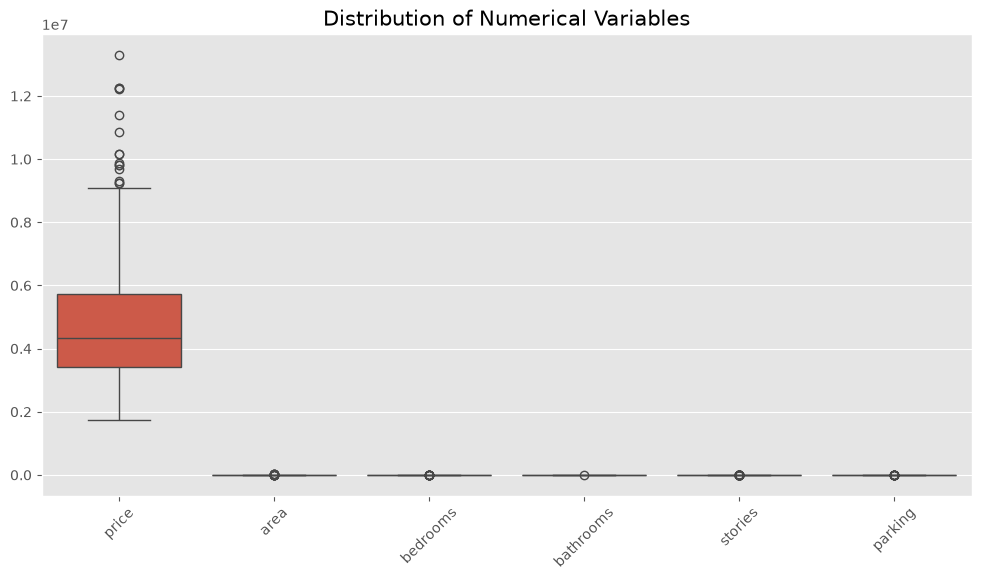

In [13]:
plt.figure(figsize=(12,6))

sns.boxplot(data=numeric_columns)

plt.title("Distribution of Numerical Variables", fontsize=15)
plt.xticks(rotation=45)

plt.show()



The measures of dispersion provide valuable insights into the variability of the housing dataset.

- The **Range** highlights the overall spread between the smallest and largest observations.
- The **Variance** and **Standard Deviation** quantify how much each numerical variable deviates from its mean.
- The **Interquartile Range (IQR)** focuses on the middle 50% of observations, making it more resistant to extreme values.
- The box plot visually identifies variables with greater variability and highlights any potential outliers.

Together, these measures complement the measures of central tendency and provide a more complete understanding of the dataset's distribution.

#  Violin Plot of House Prices

A violin plot combines the features of a box plot with a density plot.

It provides additional insight into:

- Distribution shape
- Data spread
- Density of observations
- Potential skewness

Unlike a box plot, the violin plot illustrates where observations are most concentrated.

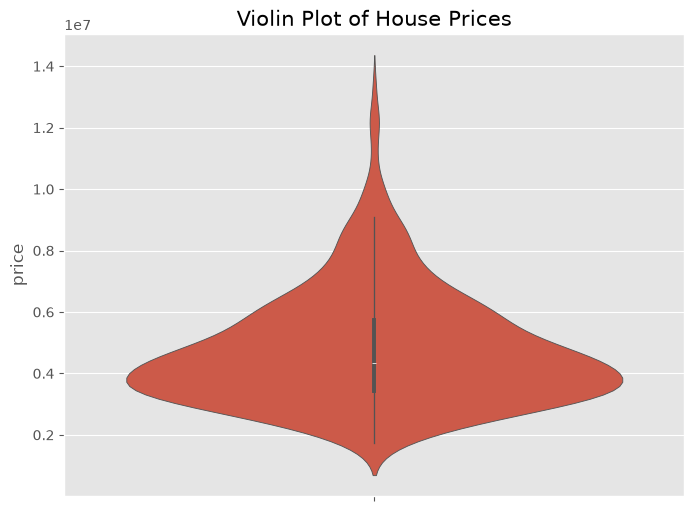

In [14]:
plt.figure(figsize=(8,6))

sns.violinplot(
    y=df["price"]
)

plt.title("Violin Plot of House Prices", fontsize=15)

plt.show()



The violin plot illustrates both the spread and density of house prices.

Wider sections indicate where observations are more concentrated, while narrower sections represent fewer observations. This visualization provides a deeper understanding of the distribution compared to summary statistics alone.

#  Probability Concepts

Probability is the branch of statistics that measures the likelihood of an event occurring. It is expressed as a value between **0 and 1**, where:

- **0** indicates an impossible event.
- **1** indicates a certain event.

Probability helps data analysts quantify uncertainty and make informed predictions based on available data.



In this section, probability concepts are demonstrated using the Housing dataset.

## Example 1: Probability of Selecting a House with Air Conditioning

This example calculates the probability that a randomly selected house has air conditioning installed.

This probability is determined by dividing the number of houses with air conditioning by the total number of houses in the dataset.

In [15]:
# Probability of a house having air conditioning

total_houses = len(df)

air_conditioned = len(df[df["airconditioning"] == "yes"])

prob_airconditioning = air_conditioned / total_houses

print(f"Probability of selecting a house with air conditioning: {prob_airconditioning:.3f}")

Probability of selecting a house with air conditioning: 0.316


## Example 2: Probability of Selecting a House Located in a Preferred Area

This example estimates the likelihood that a randomly selected house is located in a preferred residential area.

In [16]:
preferred = len(df[df["prefarea"] == "yes"])

prob_preferred = preferred / total_houses

print(f"Probability of selecting a house in a preferred area: {prob_preferred:.3f}")

Probability of selecting a house in a preferred area: 0.235


## Example 3: Probability of Selecting a House with More Than Three Bedrooms

This example calculates the probability that a randomly selected house contains more than three bedrooms.

In [17]:
large_house = len(df[df["bedrooms"] > 3])

prob_large = large_house / total_houses

print(f"Probability of selecting a house with more than three bedrooms: {prob_large:.3f}")

Probability of selecting a house with more than three bedrooms: 0.196


#  Comparing Event Probabilities

The following bar chart compares the probabilities of three events:

- House has air conditioning.
- House is located in a preferred area.
- House has more than three bedrooms.

This visualization makes it easier to compare the relative likelihood of each event.

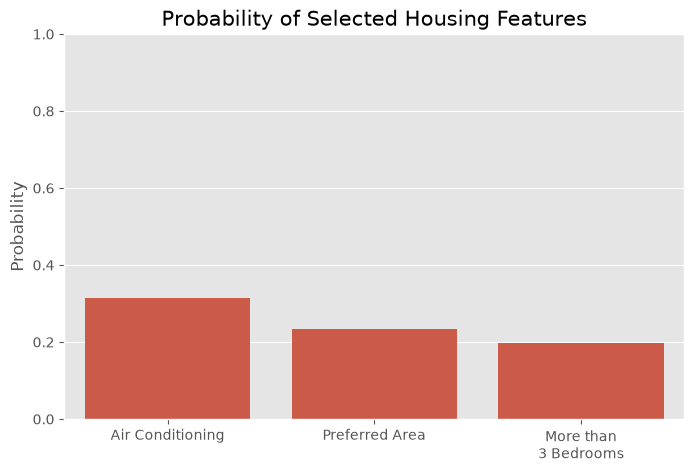

In [18]:
events = [
    "Air Conditioning",
    "Preferred Area",
    "More than\n3 Bedrooms"
]

probabilities = [
    prob_airconditioning,
    prob_preferred,
    prob_large
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=events,
    y=probabilities
)

plt.title("Probability of Selected Housing Features", fontsize=15)
plt.ylabel("Probability")
plt.ylim(0,1)

plt.show()



The calculated probabilities indicate the likelihood of encountering specific housing characteristics within the dataset.

The visualization shows that some features occur more frequently than others, highlighting differences in the distribution of property characteristics. Such probability estimates are valuable in predictive analytics and support data-driven decision-making by quantifying the likelihood of different events.

#  Probability Distributions

A probability distribution describes how the values of a variable are distributed. It provides insight into the likelihood of different outcomes occurring within a dataset.

Understanding the distribution of data is an essential step in statistical analysis because many statistical techniques assume that data follows a particular distribution.

In this section, we explore:

- Distribution of numerical variables
- Normal distribution
- Skewness
- Kurtosis

These concepts help determine the shape, symmetry, and concentration of the data.

## Distribution of House Prices

Before performing advanced statistical analysis, it is important to understand how the target variable is distributed.

The following distribution plot combines a histogram with a Kernel Density Estimate (KDE), providing both the frequency of observations and a smooth estimate of the underlying probability density.

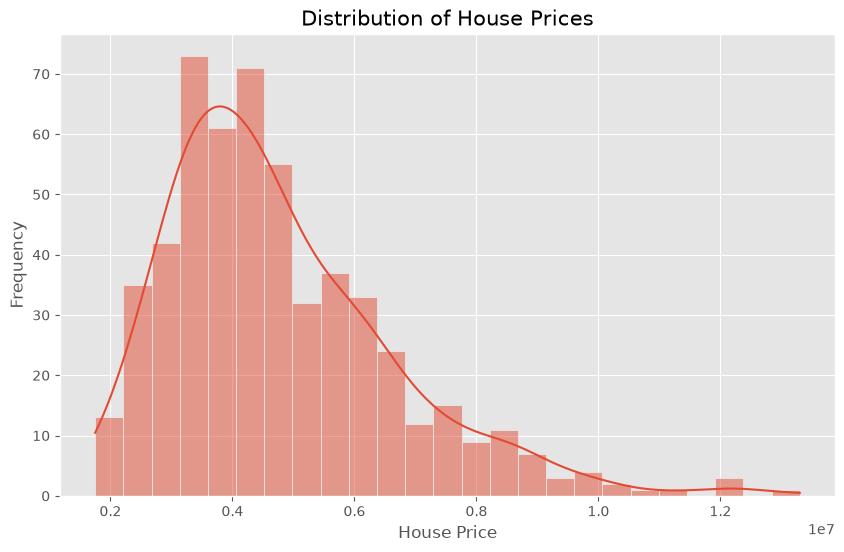

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price",
    bins=25,
    kde=True
)

plt.title("Distribution of House Prices", fontsize=15)
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

The histogram indicates how house prices are distributed throughout the dataset.

The KDE curve provides a smooth representation of the overall distribution, making it easier to identify whether the data is approximately symmetric or skewed.

Understanding the distribution is important because many statistical methods assume normally distributed data.

# Skewness

Skewness measures the degree of asymmetry in a distribution.

A distribution may be:

- Symmetric (Skewness ≈ 0)
- Positively Skewed (Right-skewed)
- Negatively Skewed (Left-skewed)

Positive skewness indicates that a small number of unusually large values pull the distribution toward the right.

Negative skewness indicates that unusually small values pull the distribution toward the left.

In [20]:
from scipy.stats import skew

price_skewness = skew(df["price"])

print(f"Skewness of House Prices: {price_skewness:.3f}")

Skewness of House Prices: 1.209


The following density plot helps visualize the symmetry (or asymmetry) of the house price distribution.

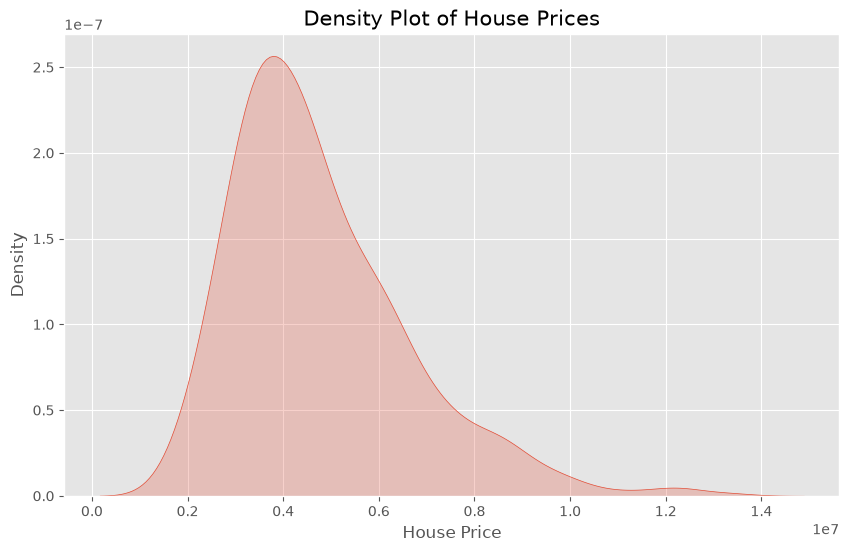

In [21]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x="price",
    fill=True
)

plt.title("Density Plot of House Prices", fontsize=15)
plt.xlabel("House Price")
plt.ylabel("Density")

plt.show()

A skewness value close to zero suggests a nearly symmetric distribution.

A positive skewness indicates that high-priced houses create a longer right tail.

A negative skewness indicates that lower-priced houses create a longer left tail.

The density plot provides a visual confirmation of the skewness value.

# Kurtosis

Kurtosis measures the "tailedness" of a distribution.

It indicates whether a dataset contains more extreme values than would normally be expected.

Generally,

- Kurtosis ≈ 0 → Similar to a normal distribution
- Positive Kurtosis → More extreme values (heavier tails)
- Negative Kurtosis → Fewer extreme values (lighter tails)

In [22]:
from scipy.stats import kurtosis

price_kurtosis = kurtosis(df["price"])

print(f"Kurtosis of House Prices: {price_kurtosis:.3f}")

Kurtosis of House Prices: 1.931


# Q–Q Plot

A Quantile–Quantile (Q–Q) plot compares the distribution of the sample data with a theoretical normal distribution.

If the points lie approximately along the reference line, the data is considered to be approximately normally distributed.

Significant deviations from the line indicate departures from normality.

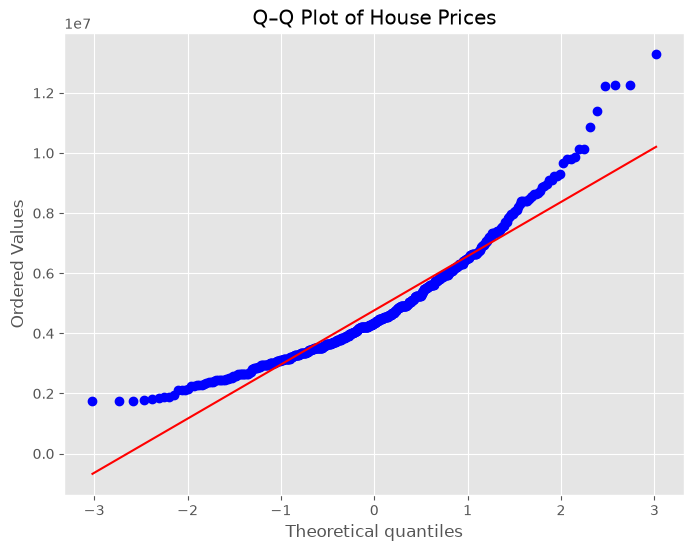

In [23]:
plt.figure(figsize=(8,6))

stats.probplot(df["price"], dist="norm", plot=plt)

plt.title("Q–Q Plot of House Prices")

plt.show()

The Q–Q plot provides a visual assessment of normality.

- Points closely following the reference line suggest that the distribution is approximately normal.
- Noticeable departures from the line indicate skewness, heavy tails, or other deviations from normality.

This assessment helps determine whether statistical methods that assume normality are appropriate for the dataset.

#  Sampling

Sampling is the process of selecting a subset of observations from a larger population.

Instead of collecting information from every member of a population, analysts use representative samples to make reliable conclusions while saving time, cost, and resources.

A good sample should accurately represent the characteristics of the population.

Common sampling techniques include:

- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling
- Cluster Sampling

In this notebook, we demonstrate **Simple Random Sampling** using the Housing dataset.

## Population vs Sample

- **Population** refers to the complete set of observations under study.
- **Sample** refers to a subset selected from the population.

In this analysis:

- **Population:** All 545 houses in the dataset.
- **Sample:** A randomly selected subset of houses used for statistical analysis.

## Simple Random Sampling

Simple Random Sampling gives every observation an equal probability of being selected.

This method minimizes selection bias and is one of the most widely used sampling techniques in statistics.

In [24]:
# Create a random sample of 100 houses

sample_df = df.sample(
    n=100,
    random_state=42
)

sample_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,4060000,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished
77,6650000,6500,3,2,3,yes,no,no,no,yes,0,yes,furnished
360,3710000,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
90,6440000,5000,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
493,2800000,3960,3,1,1,yes,no,no,no,no,0,no,furnished


## Comparing Population and Sample

A representative sample should produce summary statistics that are reasonably close to those of the population.

The following comparison helps evaluate whether the selected sample adequately represents the dataset.

In [25]:
comparison = pd.DataFrame({
    "Population Mean": numeric_columns.mean(),
    "Sample Mean": sample_df.select_dtypes(include=np.number).mean()
})

comparison

,Population Mean,Sample Mean
price,4.766729e+06,4898285.00
area,5.150541e+03,5146.98
bedrooms,2.965138e+00,2.96
bathrooms,1.286239e+00,1.34
stories,1.805505e+00,1.87
parking,6.935780e-01,0.68


#  Comparing Population and Sample Means

The grouped bar chart compares the average values of each numerical variable between the full population and the selected sample.

Small differences indicate that the sample reasonably represents the overall dataset.

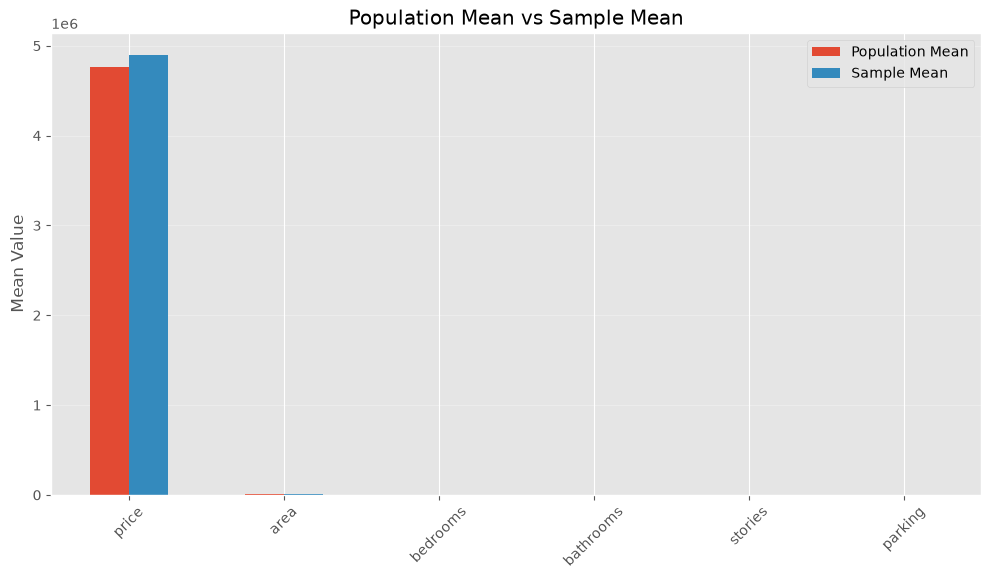

In [26]:
comparison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Population Mean vs Sample Mean")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

The grouped bar chart shows that the sample means closely resemble the population means for most numerical variables.

This suggests that the randomly selected sample is reasonably representative of the overall dataset, supporting its use for statistical analysis and inference.

# Sampling Distribution

A sampling distribution is the distribution of a statistic (such as the sample mean) obtained from many repeated random samples of the same size.

According to the **Central Limit Theorem (CLT)**, when the sample size is sufficiently large, the distribution of sample means tends to approximate a normal distribution, regardless of the original population distribution.

This principle forms the foundation of confidence intervals and hypothesis testing.

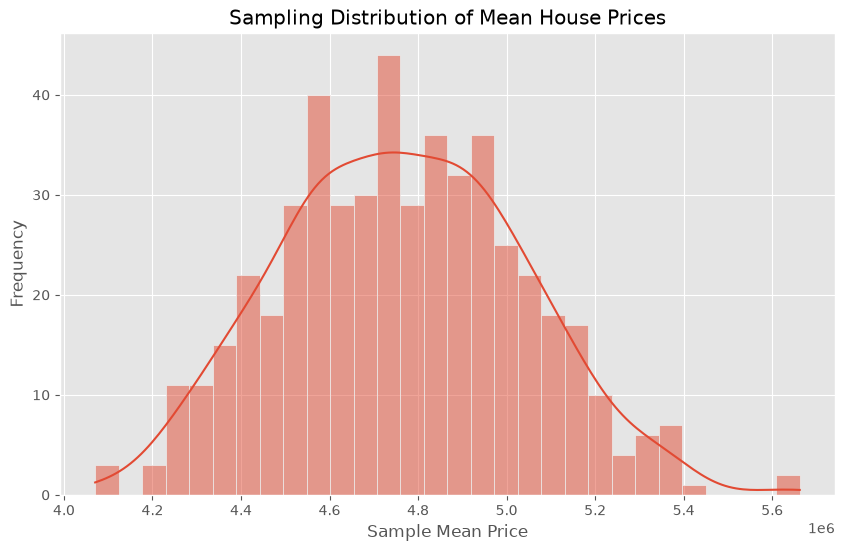

In [27]:
# Generate sampling distribution

sample_means = []

for _ in range(500):
    sample = df["price"].sample(n=50, replace=True)
    sample_means.append(sample.mean())

plt.figure(figsize=(10,6))

sns.histplot(sample_means, bins=30, kde=True)

plt.title("Sampling Distribution of Mean House Prices")
plt.xlabel("Sample Mean Price")
plt.ylabel("Frequency")

plt.show()

The sampling distribution illustrates how the sample mean varies across repeated random samples.

Although individual samples differ slightly, the sample means cluster around the population mean and form an approximately normal distribution. This demonstrates the Central Limit Theorem and highlights why sample statistics are effective for estimating population parameters.

#  Confidence Intervals

A confidence interval is a range of values that is likely to contain the true population parameter with a specified level of confidence.

Instead of estimating a single value, confidence intervals provide an interval estimate that accounts for sampling variability.

A **95% confidence interval** is commonly used, meaning that if many random samples were drawn and intervals computed, approximately 95% of those intervals would contain the true population mean.

## Confidence Interval for Mean House Price

In this section, we estimate the **95% confidence interval** for the average house price using the Housing dataset.

This provides a range within which the true average house price is expected to lie with 95% confidence.

In [28]:
from scipy.stats import t

# House prices
prices = df["price"]

# Sample statistics
n = len(prices)
mean = prices.mean()
std = prices.std()

# Standard Error
se = std / np.sqrt(n)

# Margin of Error
margin = t.ppf(0.975, df=n-1) * se

# Confidence Interval
lower = mean - margin
upper = mean + margin

print(f"Sample Mean: {mean:,.2f}")
print(f"95% Confidence Interval: ({lower:,.2f}, {upper:,.2f})")

Sample Mean: 4,766,729.25
95% Confidence Interval: (4,609,345.15, 4,924,113.35)


#  Confidence Interval of Mean House Price

The error bar below represents the estimated mean house price together with its 95% confidence interval.

The central point represents the sample mean, while the vertical error bar shows the margin of error.

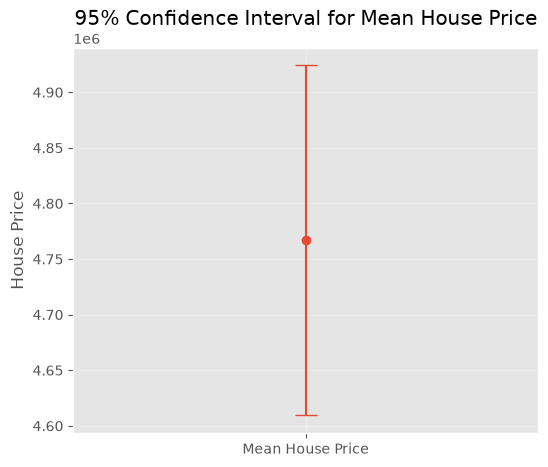

In [29]:
plt.figure(figsize=(6,5))

plt.errorbar(
    x=1,
    y=mean,
    yerr=margin,
    fmt='o',
    capsize=8
)

plt.xticks([1], ["Mean House Price"])
plt.ylabel("House Price")
plt.title("95% Confidence Interval for Mean House Price")

plt.grid(alpha=0.3)

plt.show()

The sample mean represents the estimated average house price within the dataset.

The confidence interval provides a range of plausible values for the true population mean.

A narrower confidence interval indicates greater precision in the estimate, while a wider interval suggests increased uncertainty.

#  Hypothesis Testing

Hypothesis testing is a statistical procedure used to determine whether there is sufficient evidence to support a claim about a population.

It involves two competing hypotheses:

- **Null Hypothesis (H₀):** Assumes no significant difference or relationship exists.
- **Alternative Hypothesis (H₁):** Assumes a significant difference or relationship exists.

A **p-value** is used to determine whether the null hypothesis should be rejected.

Decision Rule:

- If **p-value < 0.05**, reject the null hypothesis.
- If **p-value ≥ 0.05**, fail to reject the null hypothesis.

In [30]:
# Split the data

ac_yes = df[df["airconditioning"] == "yes"]["price"]
ac_no = df[df["airconditioning"] == "no"]["price"]

# Independent t-test

t_stat, p_value = stats.ttest_ind(
    ac_yes,
    ac_no,
    equal_var=False
)

print("T-statistic:", round(t_stat,3))
print("P-value:", round(p_value,5))

T-statistic: 10.659
P-value: 0.0


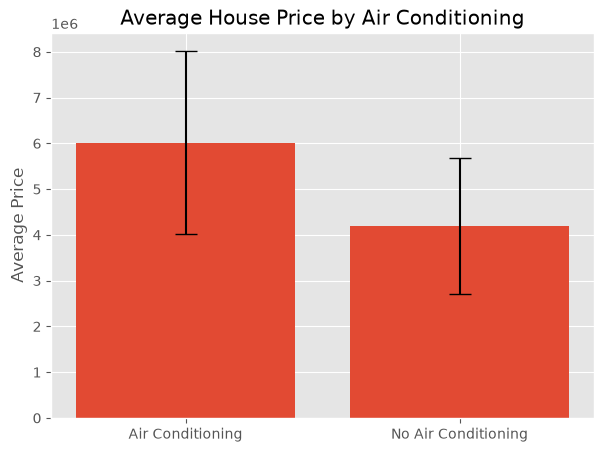

In [31]:
group_means = [
    ac_yes.mean(),
    ac_no.mean()
]

group_std = [
    ac_yes.std(),
    ac_no.std()
]

plt.figure(figsize=(7,5))

plt.bar(
    ["Air Conditioning", "No Air Conditioning"],
    group_means,
    yerr=group_std,
    capsize=8
)

plt.title("Average House Price by Air Conditioning")
plt.ylabel("Average Price")

plt.show()

The independent samples t-test evaluates whether the average selling prices differ significantly between houses with and without air conditioning.

- If the **p-value is less than 0.05**, we conclude that the difference in average prices is statistically significant.
- If the **p-value is greater than or equal to 0.05**, there is insufficient evidence to conclude that air conditioning has a significant effect on house prices.

This analysis demonstrates how hypothesis testing supports evidence-based decision-making rather than relying on assumptions alone.

# 🔗 Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between two numerical variables.

The correlation coefficient ranges from **-1 to +1**.

| Correlation Coefficient | Interpretation |
|-------------------------|----------------|
| +1 | Perfect Positive Correlation |
| 0 | No Linear Correlation |
| -1 | Perfect Negative Correlation |

Generally,

- **0.80 – 1.00** → Very Strong Correlation
- **0.60 – 0.79** → Strong Correlation
- **0.40 – 0.59** → Moderate Correlation
- **0.20 – 0.39** → Weak Correlation
- **0.00 – 0.19** → Very Weak or No Correlation

Understanding correlations helps identify the variables that most strongly influence house prices and supports better feature selection for predictive modelling.

## Correlation Matrix

A correlation matrix summarizes the pairwise correlation coefficients between all numerical variables.

It provides a quick overview of how variables are related before visualizing the relationships using a heatmap.

In [32]:
# Correlation Matrix

correlation_matrix = numeric_columns.corr()

correlation_matrix

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


## Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix.

- Darker colors indicate stronger relationships.
- Positive values indicate variables that increase together.
- Negative values indicate inverse relationships.

The heatmap makes it easier to identify variables that are strongly associated with house prices.

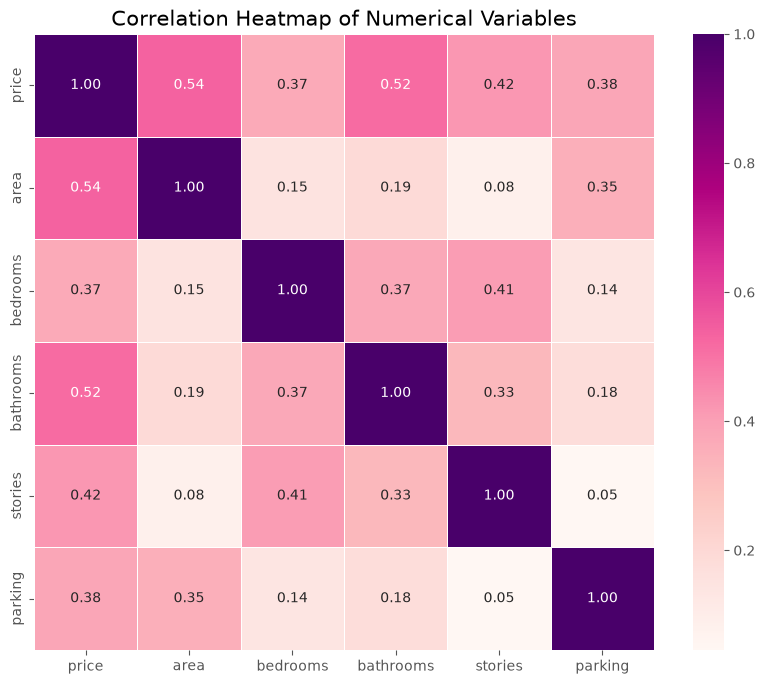

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdPu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables", fontsize=15)

plt.show()

#  Pairwise Relationships Among Key Housing Variables

The correlation matrix provides numerical measures of association between variables, while a pair plot offers a visual representation of these relationships.

This visualization examines the interactions among the key numerical variables that influence house prices:

- Price
- Area
- Bedrooms
- Bathrooms
- Stories
- Parking

The pair plot helps identify trends, clusters, and potential relationships that support a deeper understanding of the housing market.

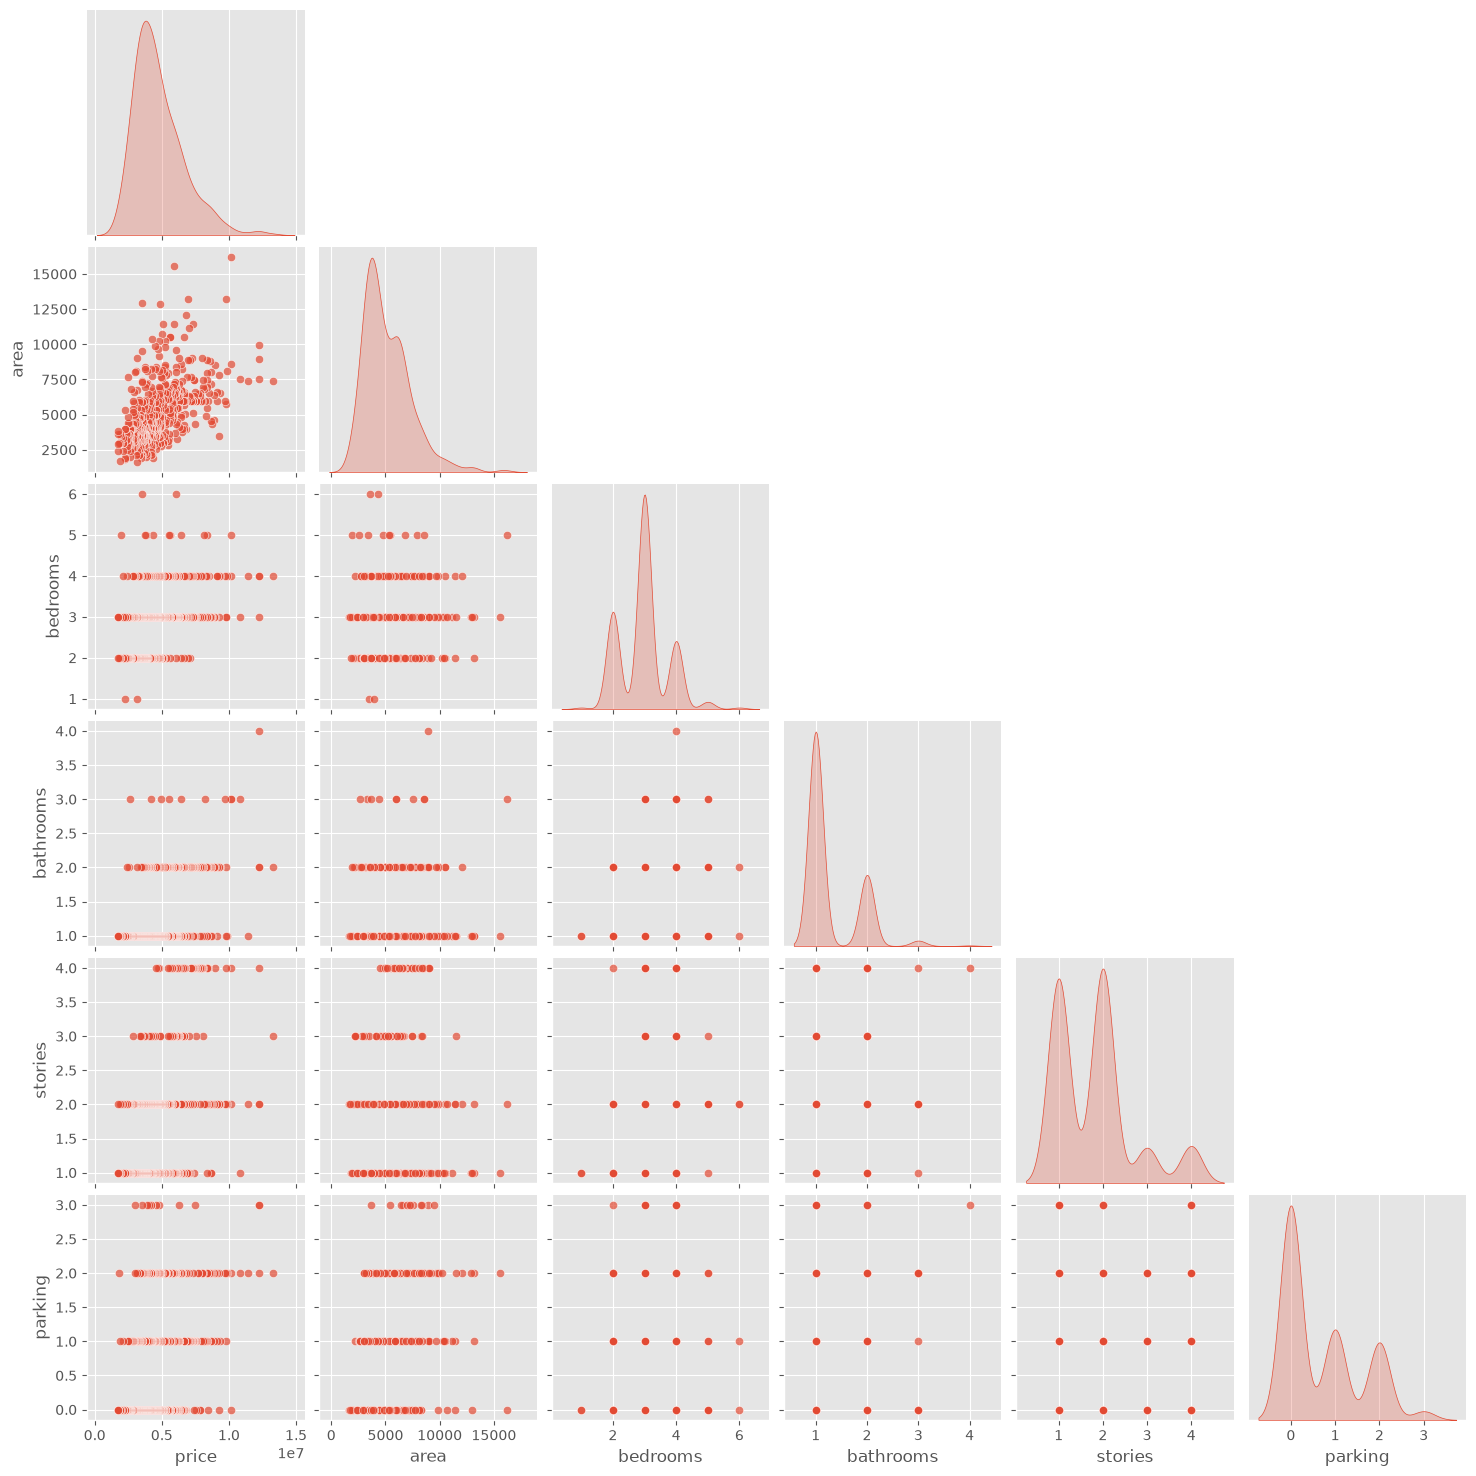

In [34]:
# Select key numerical variables

pairplot_data = df[
    ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
]

# Create pair plot

sns.pairplot(
    pairplot_data,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha":0.7}
)

plt.show()

### Interpretation

The pair plot provides a comprehensive view of the relationships among the key numerical variables in the Housing dataset.

Several meaningful patterns emerge from the visualization. Larger houses generally occupy greater areas and often include more bedrooms and bathrooms. House price tends to increase with area, the number of bathrooms, and the number of stories, although the strength of these relationships varies across observations.

Parking capacity also shows a positive association with house price, though the relationship appears weaker than those observed for area and bathrooms. The scatter plots indicate that while some variables exhibit moderate positive relationships, the data also contain considerable variation, suggesting that house prices are influenced by multiple factors rather than a single characteristic.

Overall, the pair plot complements the correlation analysis by revealing distribution patterns, trends, and potential relationships that are not fully captured by numerical correlation coefficients alone.

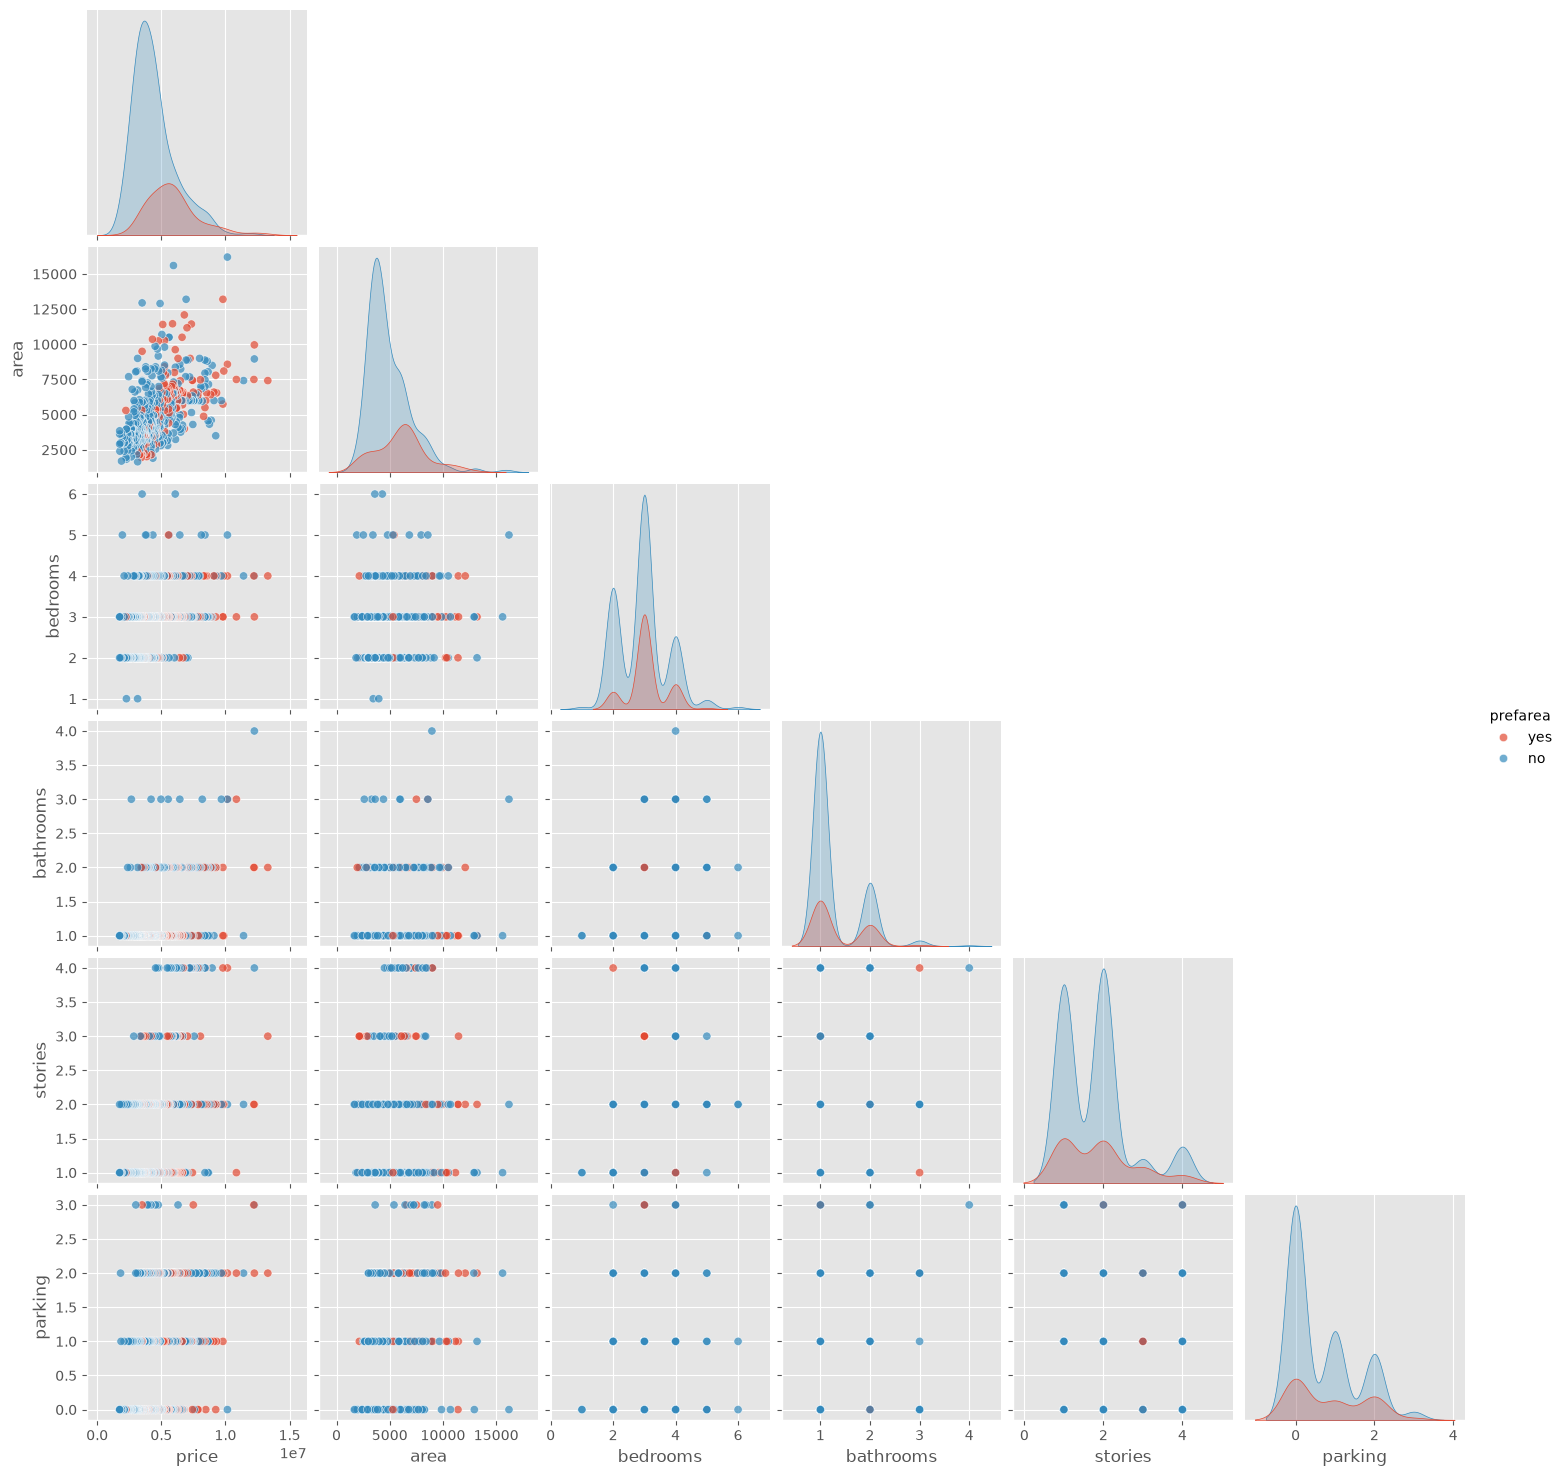

In [35]:
pairplot_data = df[
    ["price", "area", "bedrooms", "bathrooms", "stories", "parking", "prefarea"]
]

sns.pairplot(
    pairplot_data,
    hue="prefarea",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha":0.7}
)

plt.show()

## Features Most Associated with House Price

The following analysis ranks numerical variables according to their correlation with house price.

This helps identify the features that may have the greatest influence on property prices.

In [36]:
price_correlation = (
    correlation_matrix["price"]
    .drop("price")
    .sort_values(ascending=False)
)

price_correlation

area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

## Feature Importance Based on Correlation

The bar chart below ranks the numerical variables according to their correlation with house price.

Variables with larger positive coefficients tend to increase together with house prices, while negative coefficients indicate an inverse relationship.

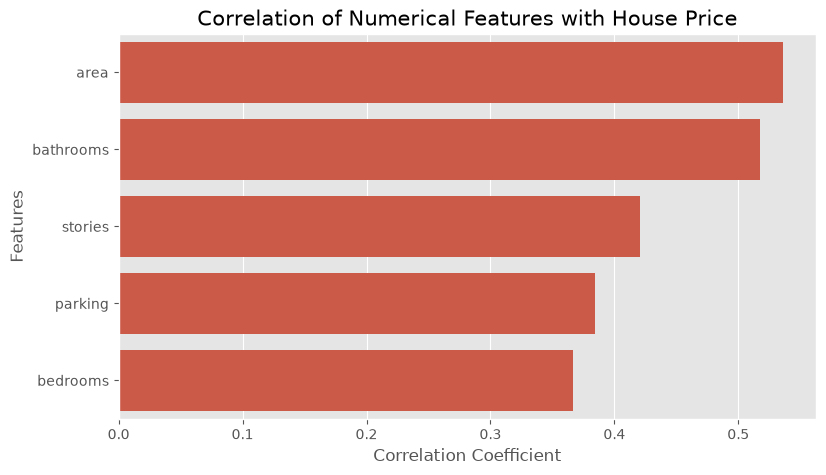

In [37]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=price_correlation.values,
    y=price_correlation.index
)

plt.title("Correlation of Numerical Features with House Price", fontsize=15)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

The correlation analysis reveals the strength of the linear relationships between house price and the numerical features.

Features with higher positive correlation coefficients are more strongly associated with increased property prices, while weaker correlations indicate a smaller linear influence.

Although correlation does not imply causation, it provides valuable insight into which variables are likely to be important predictors in future machine learning models.

###  Summary

This notebook explored the fundamental concepts of Statistics and Probability using the Housing dataset.

The analysis covered:

- Descriptive Statistics
- Measures of Central Tendency
- Measures of Dispersion
- Probability Concepts
- Probability Distributions
- Sampling Techniques
- Confidence Intervals
- Hypothesis Testing
- Correlation Analysis

Through these techniques, we gained a deeper understanding of the dataset's characteristics, variability, relationships, and statistical properties. The findings demonstrate how statistical methods support evidence-based decision-making and provide a solid foundation for predictive modelling and machine learning.

###  Key Takeaways

- Descriptive statistics provided an overview of the dataset's numerical and categorical features.
- Measures of central tendency and dispersion explained the distribution and variability of the data.
- Probability concepts demonstrated how to quantify the likelihood of different housing characteristics.
- Probability distributions helped assess the shape and normality of numerical variables.
- Sampling illustrated how representative subsets can be used to estimate population characteristics.
- Confidence intervals quantified the uncertainty surrounding population estimates.
- Hypothesis testing enabled objective decision-making based on statistical evidence.
- Correlation analysis identified the numerical variables most strongly associated with house prices, providing valuable insights for future predictive modelling.

#  Conclusion

This notebook demonstrated the practical application of statistical and probability concepts using the Housing dataset. Through descriptive statistics, probability analysis, sampling, confidence intervals, hypothesis testing, and correlation analysis, meaningful insights were obtained regarding the characteristics and relationships within the data.

The techniques applied in this analysis form a strong statistical foundation for future machine learning tasks, where understanding data distributions, variability, and relationships is essential for developing reliable predictive models.

# 📚 References

1. Analyst Lab Africa Data Science Internship Handbook.
2. Pandas Documentation. https://pandas.pydata.org/
3. NumPy Documentation. https://numpy.org/
4. Matplotlib Documentation. https://matplotlib.org/
5. Seaborn Documentation. https://seaborn.pydata.org/
6. SciPy Documentation. https://docs.scipy.org/